# P4 — Surface Completion Experiments

Evaluates how well each VAE variant can reconstruct missing regions of implied volatility surfaces.  
Two experimental modes:
1. **Random masking** — uniformly random cells hidden at 0/10/25/50/75/90% rates, averaged over 5 seeds.
2. **Structured masking** — four financially-motivated patterns: OTM wings, short-dated tenors, long-dated tenors, corners.

**Scope:** 8 tickers × 6 VAE variants = 48 models  
**Test set:** 244 dates per ticker (chronological last 10%)  
**Metric:** MAE in vol points on *masked cells only* (cells the model had to infer)  
At mask_ratio=0% the model sees the full surface → reports normal reconstruction MAE (sanity check).

In [2]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})
warnings.filterwarnings('ignore')

# ── project root ─────────────────────────────────────────────────────────────
ROOT = Path(os.getcwd())
if (ROOT / 'src').exists():
    pass
else:
    ROOT = ROOT.parent.parent  # notebooks/experiments/ → project root
sys.path.insert(0, str(ROOT))

from src.models import create_model
from src.data.dataloaders import create_dataloaders
from src.utils.masking import (
    create_structured_mask,
    evaluate_completion_multiseed,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── constants ─────────────────────────────────────────────────────────────────
TICKERS  = ['AAPL', 'GOOGL', 'NVDA', 'TSLA', 'F', 'XOM', 'CVX', 'VIX']
VARIANTS = ['mlp', 'mlp_log', 'mlp_log_arb', 'conv', 'conv_log', 'conv_log_arb']
VARIANT_LABELS = {
    'mlp': 'MLP', 'mlp_log': 'MLP-log', 'mlp_log_arb': 'MLP-log-arb',
    'conv': 'Conv', 'conv_log': 'Conv-log', 'conv_log_arb': 'Conv-log-arb',
}
VARIANT_COLORS = {
    'mlp': '#1f77b4', 'mlp_log': '#ff7f0e', 'mlp_log_arb': '#d62728',
    'conv': '#2ca02c', 'conv_log': '#9467bd', 'conv_log_arb': '#8c564b',
}
MASK_RATIOS      = [0.0, 0.10, 0.25, 0.50, 0.75, 0.90]
N_SEEDS          = 5    # seeds averaged per (date, mask_ratio)
STRUCTURED_TYPES = ['otm', 'short_maturity', 'long_maturity', 'corners']
STRUCT_LABELS    = {
    'otm':            'OTM Wings',
    'short_maturity': 'Short-dated Tenors',
    'long_maturity':  'Long-dated Tenors',
    'corners':        'Corners (OTM + Long)',
}
GRID_SHAPE = (2, 11, 17)   # (C, H, W)

# Output directories
OUT_ROOT = ROOT / 'artifacts' / 'completion'
OUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUT_ROOT / 'summary' / 'plots').mkdir(parents=True, exist_ok=True)
for t in TICKERS:
    (OUT_ROOT / t / 'plots').mkdir(parents=True, exist_ok=True)

print('Output root:', OUT_ROOT)

Device: cuda
Output root: c:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\completion


In [3]:
# ── helpers ───────────────────────────────────────────────────────────────────

_bundle_cache = {}   # (ticker, log_transform) -> DataLoaderBundle
_xtest_cache  = {}   # (ticker, log_transform) -> X_test tensor (CPU, normalised)


def _get_bundle(ticker: str, log_transform: bool):
    """Load (and cache) the DataLoader bundle for a ticker/transform combo."""
    key = (ticker, log_transform)
    if key not in _bundle_cache:
        parquet = ROOT / 'data' / 'processed' / 'vae' / 'parquet' / f'{ticker}_vsurf_processed.parquet'
        bundle = create_dataloaders(
            parquet_path=str(parquet),
            batch_size=64,
            normalize=True,
            use_log_transform=log_transform,
            return_date=False,
            num_workers=0,
        )
        _bundle_cache[key] = bundle

        # Collect test set as a single tensor (normalised, on CPU)
        X_list = []
        for batch in bundle.test_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            X_list.append(x)
        _xtest_cache[key] = torch.cat(X_list, dim=0)

    return _bundle_cache[key], _xtest_cache[key]


def load_model_and_data(ticker: str, variant: str):
    """Return (model, scaler, X_test) ready for evaluate_completion_multiseed."""
    ckpt_path = ROOT / 'artifacts' / 'train' / ticker / variant / 'vae_checkpoint.pt'
    ckpt = torch.load(str(ckpt_path), map_location='cpu', weights_only=False)

    train_args  = ckpt['args']
    log_tf      = train_args.get('log_transform', False)
    model_type  = ckpt.get('model_type', train_args.get('model_type', 'mlp'))
    input_shape = tuple(ckpt['input_shape'])

    bundle, X_test = _get_bundle(ticker, log_tf)

    model = create_model(
        model_type  = model_type,
        in_shape    = input_shape,
        latent_dim  = train_args.get('latent_dim', 24),
        hidden_dims = tuple(train_args.get('hidden_dims', [384, 192])),
        channels    = tuple(train_args.get('channels',    [32, 64, 128])),
        fc_dim      = train_args.get('fc_dim', 128),
        batchnorm   = not train_args.get('no_batchnorm', False),
    )
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval().to(DEVICE)

    scaler = bundle.scaler
    scaler.to(DEVICE)

    return model, scaler, X_test


print('Helpers defined.')

Helpers defined.


In [16]:
# Full-run scope
TICKERS = ['AAPL', 'GOOGL', 'NVDA', 'TSLA', 'F', 'XOM', 'CVX', 'VIX']
for t in TICKERS:
    (OUT_ROOT / t / 'plots').mkdir(parents=True, exist_ok=True)
print('Full scope:', TICKERS)

Full scope: ['AAPL', 'GOOGL', 'NVDA', 'TSLA', 'F', 'XOM', 'CVX', 'VIX']


## 1. Random Mask Sweep

For each **(ticker, variant, mask_ratio)** triple we run `evaluate_completion_multiseed`  
(5 seeds × 244 dates, unique mask per date).  Results saved to `artifacts/completion/{TICKER}/random_masks.csv`.

In [17]:
import time

for ticker in TICKERS:
    print('\n' + '=' * 60)
    print(f'  {ticker}')
    print('=' * 60)
    records = []
    per_date_store = {}   # variant -> {mask_ratio -> per_date_mae array}

    for variant in VARIANTS:
        print(f'  {VARIANT_LABELS[variant]:15s}', end=' ', flush=True)
        t0 = time.time()
        try:
            model, scaler, X_test = load_model_and_data(ticker, variant)
            per_date_store[variant] = {}

            for mask_ratio in MASK_RATIOS:
                mae, rmse, per_date = evaluate_completion_multiseed(
                    model=model, X_test=X_test, scaler=scaler,
                    mask_ratio=mask_ratio, n_seeds=N_SEEDS, device=DEVICE,
                )
                records.append({
                    'variant':    variant,
                    'mask_ratio': mask_ratio,
                    'mae_vp':     mae,
                    'rmse_vp':    rmse,
                })
                per_date_store[variant][mask_ratio] = per_date

            print(f'  [{time.time()-t0:.1f}s]  MAE@50%: {records[-3]["mae_vp"]:.3f} vp')
        except Exception as e:
            print(f'  ERROR: {e}')

    # Save CSV
    df = pd.DataFrame(records)
    df.to_csv(OUT_ROOT / ticker / 'random_masks.csv', index=False)

    # Save per-date store (for AAPL scatter plot later)
    if ticker == 'AAPL':
        import pickle
        with open(OUT_ROOT / ticker / 'per_date_store.pkl', 'wb') as f:
            pickle.dump(per_date_store, f)

print('\nRandom mask sweep complete.')


  AAPL
  MLP               [1.2s]  MAE@50%: 0.024 vp
  MLP-log           [1.0s]  MAE@50%: 0.023 vp
  MLP-log-arb       [1.0s]  MAE@50%: 0.022 vp
  Conv              [1.3s]  MAE@50%: 0.024 vp
  Conv-log          [1.3s]  MAE@50%: 0.024 vp
  Conv-log-arb      [1.3s]  MAE@50%: 0.025 vp

  GOOGL
  MLP               [15.2s]  MAE@50%: 0.029 vp
  MLP-log           [14.8s]  MAE@50%: 0.031 vp
  MLP-log-arb       [1.1s]  MAE@50%: 0.030 vp
  Conv              [1.4s]  MAE@50%: 0.029 vp
  Conv-log          [1.3s]  MAE@50%: 0.032 vp
  Conv-log-arb      [1.3s]  MAE@50%: 0.030 vp

  NVDA
  MLP               [15.0s]  MAE@50%: 0.038 vp
  MLP-log           [14.7s]  MAE@50%: 0.040 vp
  MLP-log-arb       [1.1s]  MAE@50%: 0.041 vp
  Conv              [1.4s]  MAE@50%: 0.043 vp
  Conv-log          [1.2s]  MAE@50%: 0.042 vp
  Conv-log-arb      [1.4s]  MAE@50%: 0.039 vp

  TSLA
  MLP               [14.9s]  MAE@50%: 0.043 vp
  MLP-log           [14.7s]  MAE@50%: 0.058 vp
  MLP-log-arb       [1.1s]  MAE@50%: 0.05

## 2. Completion Curve Plots

One plot per ticker: MAE (vol points) on masked cells vs mask ratio, one line per VAE variant.

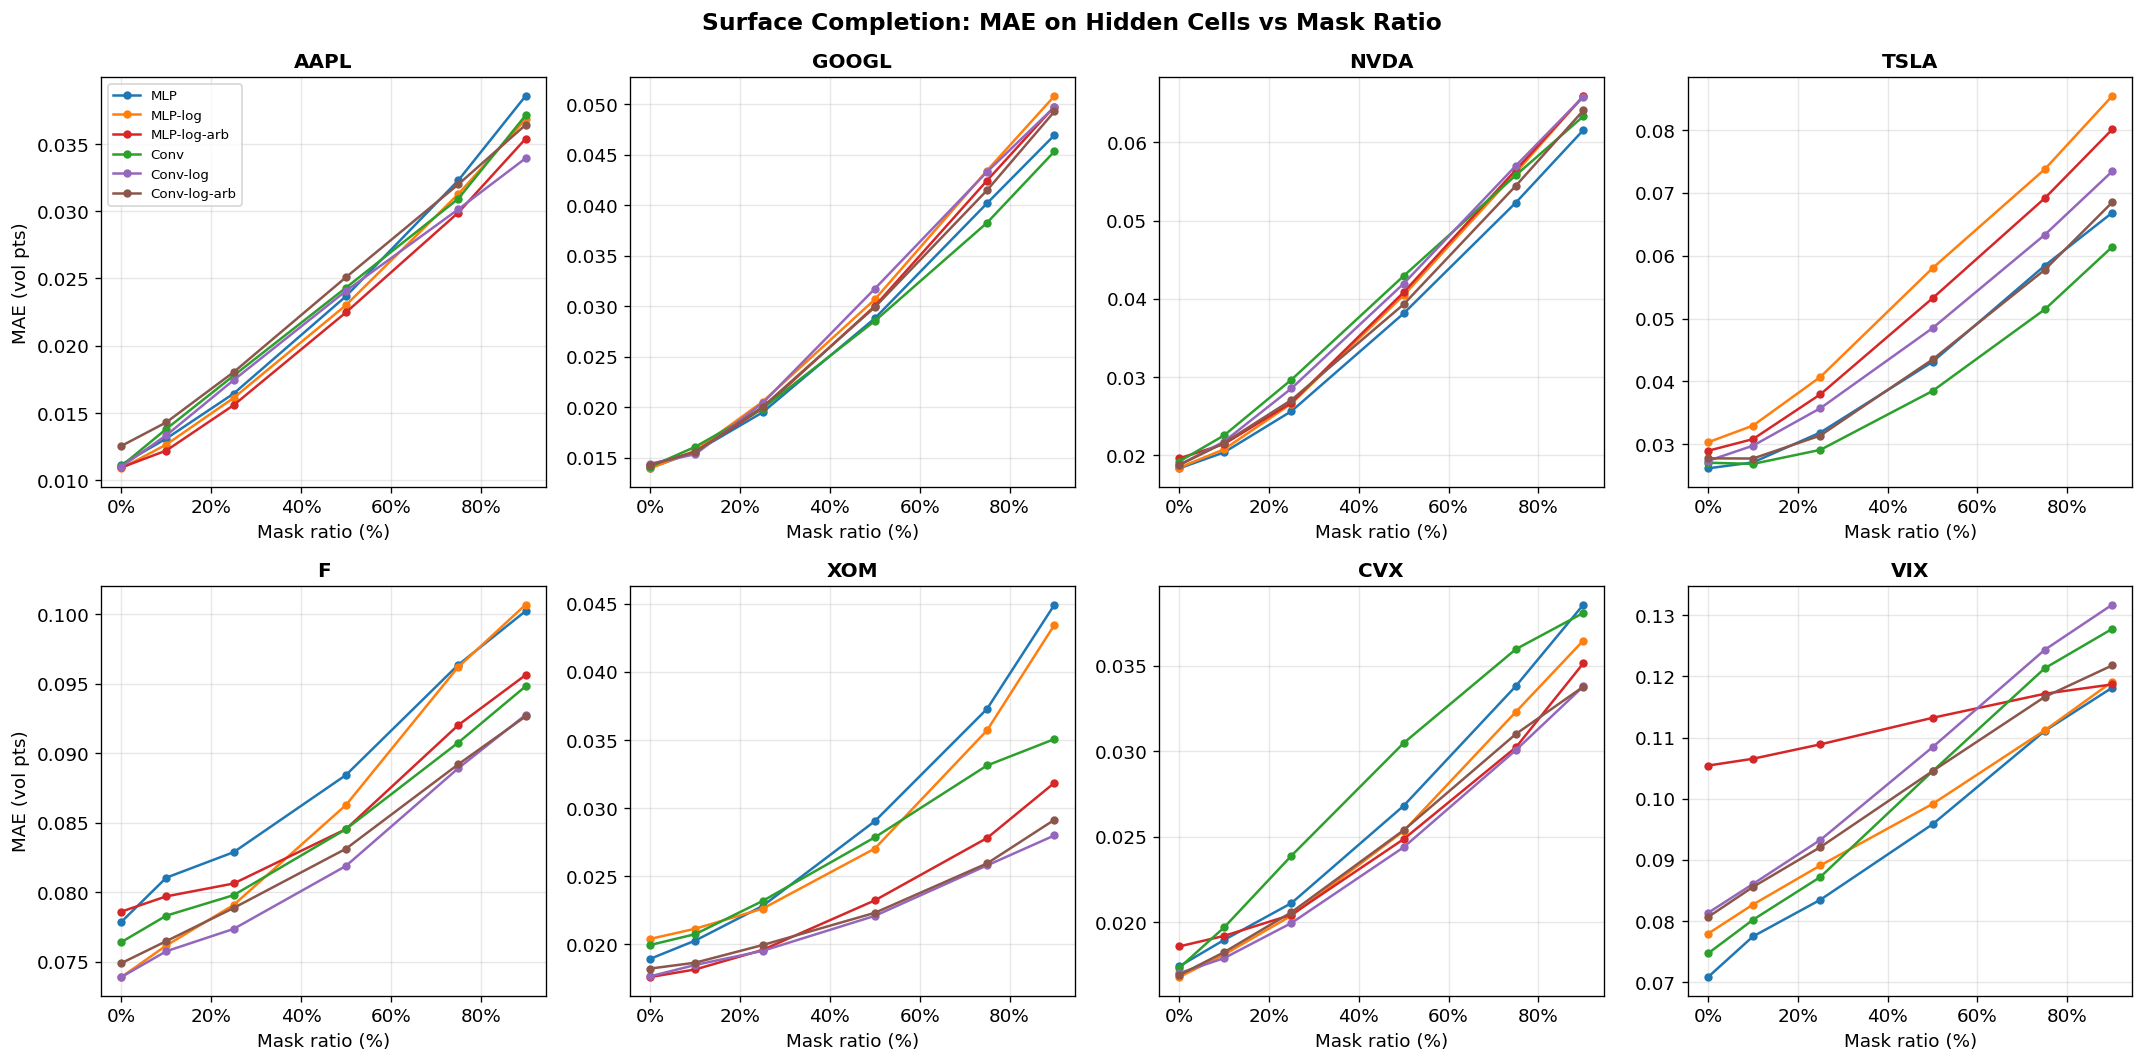

Completion curve plots saved.


In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
axes = axes.flatten()

for ax_idx, ticker in enumerate(TICKERS):
    ax = axes[ax_idx]
    csv = OUT_ROOT / ticker / 'random_masks.csv'
    if not csv.exists():
        ax.set_title(f'{ticker} — no data')
        continue

    df = pd.read_csv(csv)
    for variant in VARIANTS:
        sub = df[df['variant'] == variant].sort_values('mask_ratio')
        if sub.empty:
            continue
        ax.plot(
            sub['mask_ratio'] * 100,
            sub['mae_vp'],
            marker='o', markersize=4,
            color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant],
            linewidth=1.5,
        )

    ax.set_title(ticker, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mask ratio (%)')
    ax.set_ylabel('MAE (vol pts)' if ax_idx % 4 == 0 else '')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.grid(True, alpha=0.3)
    if ax_idx == 0:
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Surface Completion: MAE on Hidden Cells vs Mask Ratio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_ROOT / 'summary' / 'plots' / 'completion_curves_all_tickers.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Also save individual per-ticker plots
for ticker in TICKERS:
    csv = OUT_ROOT / ticker / 'random_masks.csv'
    if not csv.exists():
        continue
    df = pd.read_csv(csv)
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    for variant in VARIANTS:
        sub = df[df['variant'] == variant].sort_values('mask_ratio')
        if sub.empty:
            continue
        ax2.plot(sub['mask_ratio']*100, sub['mae_vp'],
                 marker='o', markersize=5,
                 color=VARIANT_COLORS[variant],
                 label=VARIANT_LABELS[variant], linewidth=1.8)
    ax2.set_title(f'{ticker} — Completion Curve', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Mask ratio (%)')
    ax2.set_ylabel('MAE (vol pts)')
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_ROOT / ticker / 'plots' / 'completion_curve.png',
                dpi=150, bbox_inches='tight')
    plt.close()

print('Completion curve plots saved.')

## 3. Structured Mask Analysis

Four financially-motivated mask patterns applied with a fixed mask (same for every date):  
- **OTM Wings** — deep ITM/OTM delta columns hidden (low liquidity zones)  
- **Short-dated Tenors** — earliest maturity rows hidden (bid-ask spread often very wide)  
- **Long-dated Tenors** — longest maturity rows hidden  
- **Corners** — OTM × long-dated intersection (doubly illiquid)

Each mask hides ≈ 40–50% of the grid.  Results saved to `artifacts/completion/{TICKER}/structured_masks.csv`.

In [19]:
@torch.no_grad()
def evaluate_structured(
    model, X_test: torch.Tensor, scaler, mask: torch.Tensor,
    device, batch_size: int = 32,
):
    """Evaluate a fixed structured mask on all test dates."""
    model.eval()
    N = X_test.shape[0]
    mask_g = mask.to(device)           # (C, H, W)
    n_masked = int(mask.sum())
    if n_masked == 0:
        return 0.0, 0.0

    total_abs = 0.0
    total_sq  = 0.0
    total_n   = 0

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        x_b = X_test[start:end].to(device)          # (bs, C, H, W)
        m_b = mask_g.unsqueeze(0).expand_as(x_b)   # (bs, C, H, W)

        x_masked = x_b * (1.0 - m_b)
        recon, mu, lv = model(x_masked)

        recon_orig = scaler.inverse_transform(recon).cpu()
        x_orig     = scaler.inverse_transform(x_b).cpu()
        m_cpu      = m_b.cpu()

        diff = recon_orig - x_orig
        total_abs += float((diff.abs() * m_cpu).sum())
        total_sq  += float((diff.pow(2) * m_cpu).sum())
        total_n   += int(m_cpu.sum())

    mean_mae  = total_abs / total_n
    mean_rmse = float(np.sqrt(total_sq / total_n))
    return mean_mae, mean_rmse


for ticker in TICKERS:
    print(f'\n{ticker}')
    records = []

    for variant in VARIANTS:
        try:
            model, scaler, X_test = load_model_and_data(ticker, variant)

            for mtype in STRUCTURED_TYPES:
                mask = create_structured_mask(
                    shape=GRID_SHAPE, mask_type=mtype, mask_ratio=0.45,
                    seed=42, device=torch.device('cpu'),
                )
                mae, rmse = evaluate_structured(
                    model=model, X_test=X_test, scaler=scaler,
                    mask=mask, device=DEVICE,
                )
                records.append({
                    'variant':   variant,
                    'mask_type': mtype,
                    'mae_vp':    mae,
                    'rmse_vp':   rmse,
                    'mask_pct':  float(mask.mean()) * 100,
                })

            # Summary line
            row50 = next(r for r in records[::-1]
                         if r['variant'] == variant and r['mask_type'] == 'otm')
            print(f'  {VARIANT_LABELS[variant]:15s}  OTM-MAE={row50["mae_vp"]:.3f} vp')
        except Exception as e:
            print(f'  {variant}: ERROR {e}')

    df = pd.DataFrame(records)
    df.to_csv(OUT_ROOT / ticker / 'structured_masks.csv', index=False)

print('\nStructured mask analysis complete.')


AAPL
  MLP              OTM-MAE=0.030 vp
  MLP-log          OTM-MAE=0.029 vp
  MLP-log-arb      OTM-MAE=0.028 vp
  Conv             OTM-MAE=0.031 vp
  Conv-log         OTM-MAE=0.032 vp
  Conv-log-arb     OTM-MAE=0.030 vp

GOOGL
  MLP              OTM-MAE=0.046 vp
  MLP-log          OTM-MAE=0.046 vp
  MLP-log-arb      OTM-MAE=0.038 vp
  Conv             OTM-MAE=0.045 vp
  Conv-log         OTM-MAE=0.044 vp
  Conv-log-arb     OTM-MAE=0.039 vp

NVDA
  MLP              OTM-MAE=0.046 vp
  MLP-log          OTM-MAE=0.045 vp
  MLP-log-arb      OTM-MAE=0.040 vp
  Conv             OTM-MAE=0.053 vp
  Conv-log         OTM-MAE=0.048 vp
  Conv-log-arb     OTM-MAE=0.045 vp

TSLA
  MLP              OTM-MAE=0.065 vp
  MLP-log          OTM-MAE=0.082 vp
  MLP-log-arb      OTM-MAE=0.079 vp
  Conv             OTM-MAE=0.049 vp
  Conv-log         OTM-MAE=0.058 vp
  Conv-log-arb     OTM-MAE=0.056 vp

F
  MLP              OTM-MAE=0.132 vp
  MLP-log          OTM-MAE=0.137 vp
  MLP-log-arb      OTM-MAE=0.132 vp


In [20]:
# ── Structured mask bar plots (one per ticker) ────────────────────────────────

for ticker in TICKERS:
    csv = OUT_ROOT / ticker / 'structured_masks.csv'
    if not csv.exists():
        continue
    df = pd.read_csv(csv)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
    for col_idx, mtype in enumerate(STRUCTURED_TYPES):
        ax = axes[col_idx]
        sub = df[df['mask_type'] == mtype]
        colors = [VARIANT_COLORS[v] for v in sub['variant']]
        bars = ax.bar(
            [VARIANT_LABELS[v] for v in sub['variant']],
            sub['mae_vp'],
            color=colors, edgecolor='white', linewidth=0.5,
        )
        ax.set_title(STRUCT_LABELS[mtype], fontsize=10)
        ax.set_ylabel('MAE (vol pts)' if col_idx == 0 else '')
        ax.set_xticklabels([VARIANT_LABELS[v] for v in sub['variant']],
                           rotation=35, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle(f'{ticker} — Structured Mask MAE by Region', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_ROOT / ticker / 'plots' / 'structured_bar.png',
                dpi=150, bbox_inches='tight')
    plt.close()

print('Structured bar plots saved.')

Structured bar plots saved.


## 4. Per-Date Scatter (AAPL, MLP-log, 50% Masking)

Shows whether completion difficulty varies by date (e.g., high-vol market conditions).  
Left: distribution of per-date MAE. Right: per-date MAE vs market IV level.

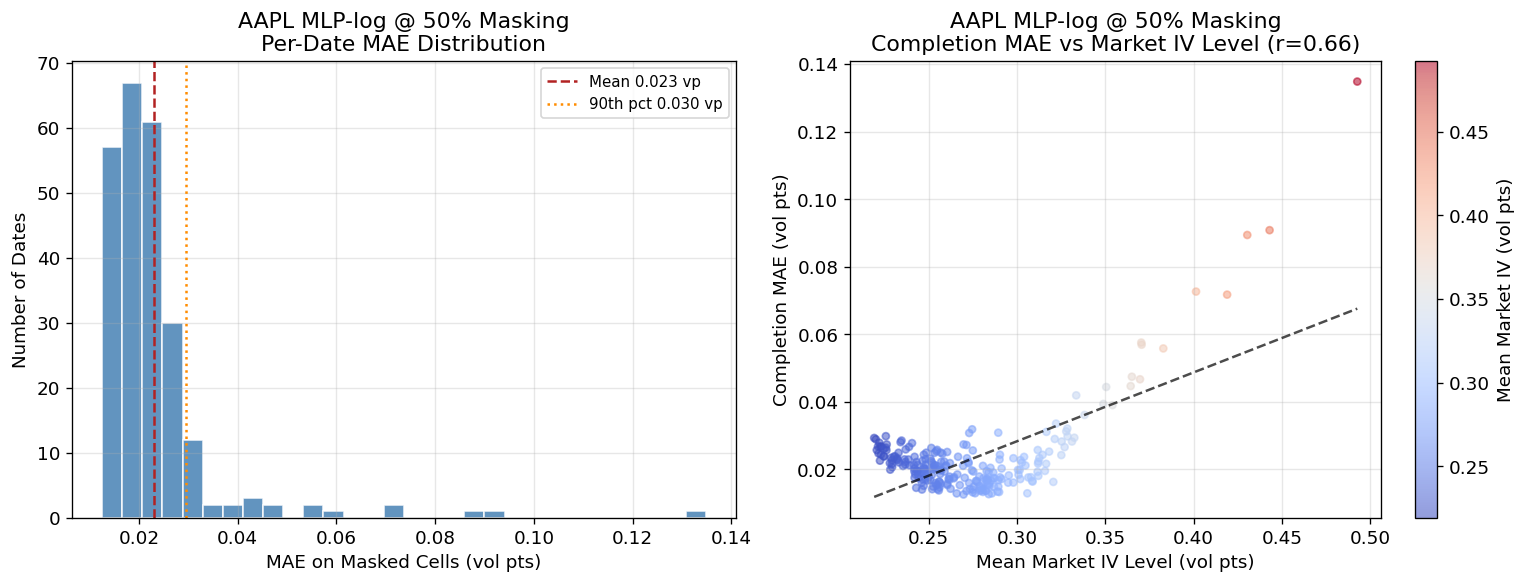

Per-date MAE: mean=0.023, std=0.013, 90th=0.030 vp


In [21]:
import pickle

store_path = OUT_ROOT / 'AAPL' / 'per_date_store.pkl'
if store_path.exists():
    with open(store_path, 'rb') as f:
        per_date_store = pickle.load(f)

    variant    = 'mlp_log'
    mask_ratio = 0.50
    per_date   = per_date_store[variant][mask_ratio]  # (244,)

    # ── Load market surface mean IV per date for labelling ──────────────────
    surf_path = ROOT / 'artifacts' / 'eval' / 'AAPL' / variant / 'surfaces' / 'market_surfaces.npy'
    mkt = np.load(surf_path)                       # (244, 2, 11, 17)
    mkt_iv_level = np.nanmean(mkt, axis=(1, 2, 3)) # (244,) mean IV per date

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Distribution of per-date MAE
    ax1.hist(per_date, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax1.axvline(per_date.mean(), color='firebrick', linestyle='--', linewidth=1.5,
                label=f'Mean {per_date.mean():.3f} vp')
    ax1.axvline(np.percentile(per_date, 90), color='darkorange', linestyle=':', linewidth=1.5,
                label=f'90th pct {np.percentile(per_date, 90):.3f} vp')
    ax1.set_xlabel('MAE on Masked Cells (vol pts)')
    ax1.set_ylabel('Number of Dates')
    ax1.set_title('AAPL MLP-log @ 50% Masking\nPer-Date MAE Distribution')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Scatter: completion MAE vs market IV level
    sc = ax2.scatter(mkt_iv_level, per_date, alpha=0.55, s=18,
                     c=mkt_iv_level, cmap='coolwarm')
    plt.colorbar(sc, ax=ax2, label='Mean Market IV (vol pts)')
    z = np.polyfit(mkt_iv_level, per_date, 1)
    xfit = np.linspace(mkt_iv_level.min(), mkt_iv_level.max(), 100)
    ax2.plot(xfit, np.polyval(z, xfit), 'k--', linewidth=1.5, alpha=0.7)
    corr = np.corrcoef(mkt_iv_level, per_date)[0, 1]
    ax2.set_xlabel('Mean Market IV Level (vol pts)')
    ax2.set_ylabel('Completion MAE (vol pts)')
    ax2.set_title(f'AAPL MLP-log @ 50% Masking\nCompletion MAE vs Market IV Level (r={corr:.2f})')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT_ROOT / 'AAPL' / 'plots' / 'per_date_scatter.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Per-date MAE: mean={per_date.mean():.3f}, std={per_date.std():.3f}, '
          f'90th={np.percentile(per_date, 90):.3f} vp')
else:
    print('Per-date store not found — run Section 1 first.')

## 5. Surface Visualisation (AAPL, MLP-log)

Show original surface, masked input, and VAE reconstruction for three representative dates:  
easiest (lowest per-date MAE), median, and hardest (highest per-date MAE).

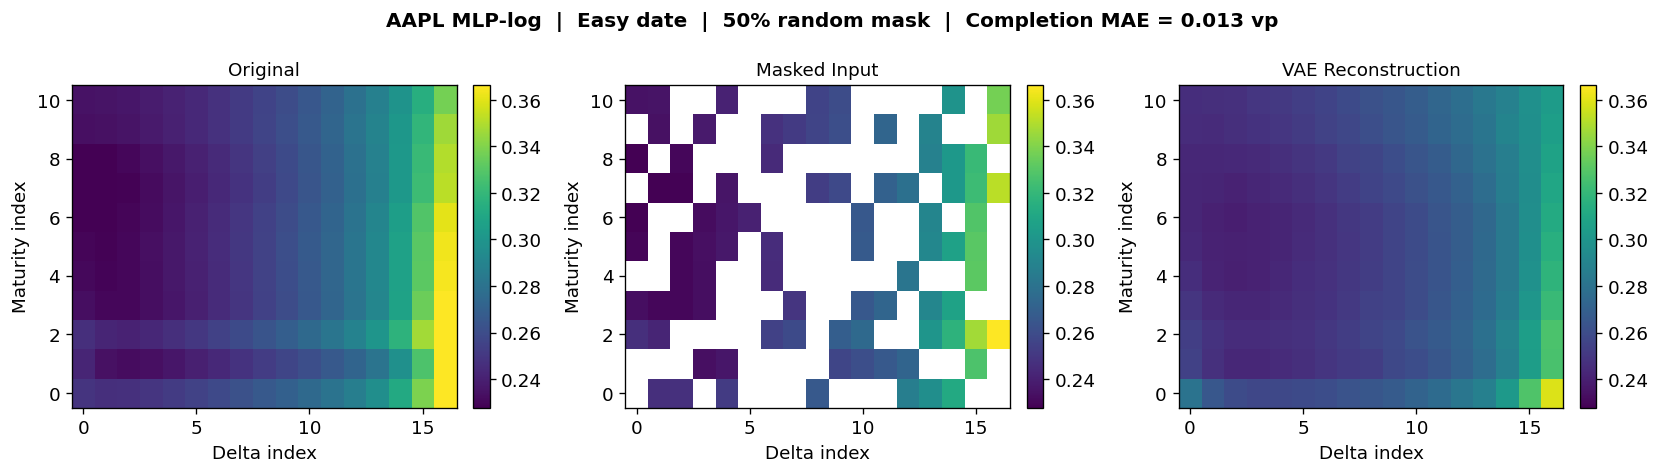

Easy date (idx=133): completion MAE = 0.013 vp


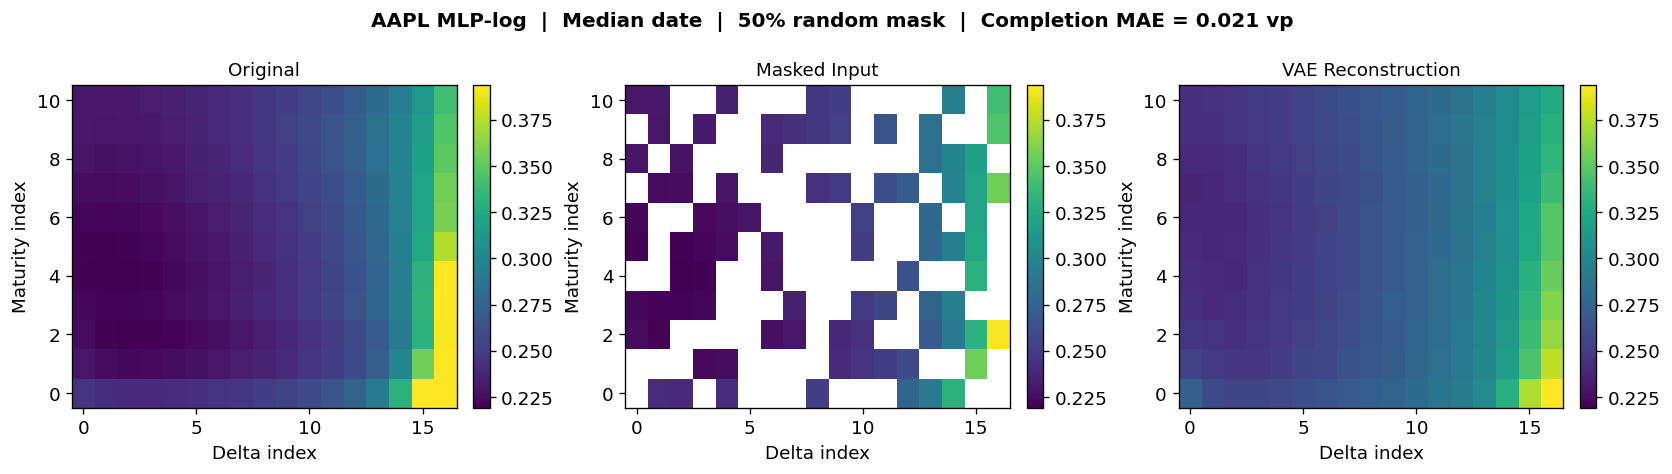

Median date (idx=242): completion MAE = 0.021 vp


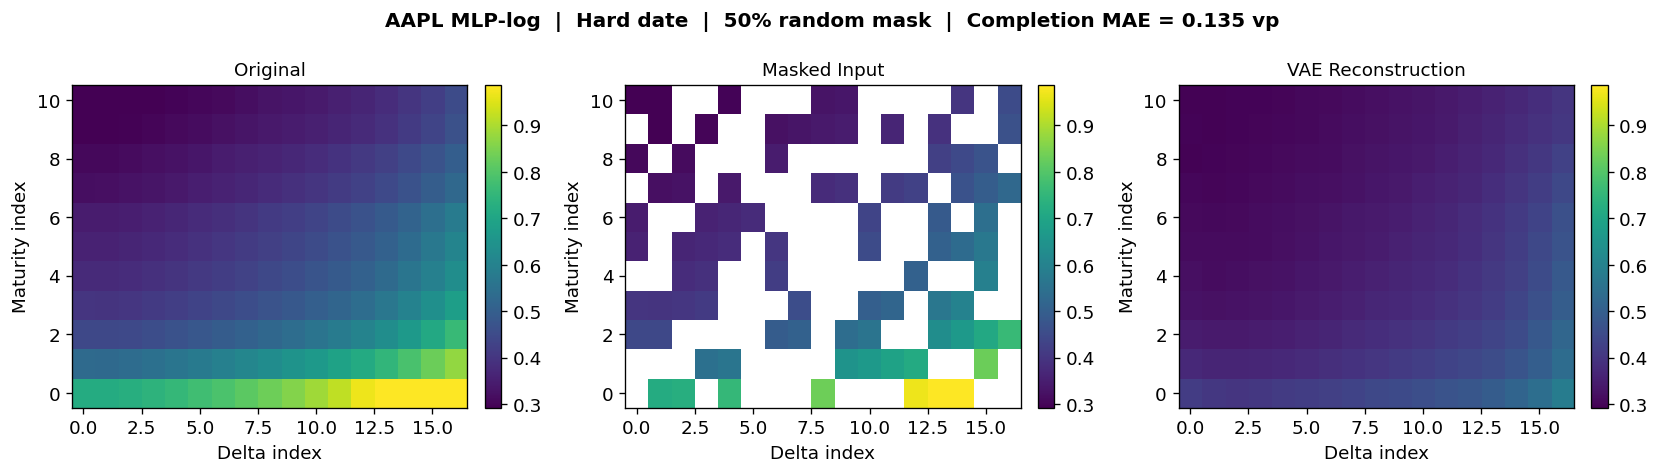

Hard date (idx=144): completion MAE = 0.135 vp


In [22]:
if store_path.exists():
    model, scaler, X_test = load_model_and_data('AAPL', 'mlp_log')
    surf_path = ROOT / 'artifacts' / 'eval' / 'AAPL' / 'mlp_log' / 'surfaces' / 'market_surfaces.npy'
    mkt_np = np.load(surf_path)  # (244, 2, 11, 17) in vol pts

    mask_ratio = 0.50
    per_date = per_date_store['mlp_log'][mask_ratio]

    # Pick three representative dates
    idx_easy   = int(np.argmin(per_date))
    idx_median = int(np.argsort(per_date)[len(per_date) // 2])
    idx_hard   = int(np.argmax(per_date))
    titles = {
        'Easy':   (idx_easy,   per_date[idx_easy]),
        'Median': (idx_median, per_date[idx_median]),
        'Hard':   (idx_hard,   per_date[idx_hard]),
    }

    # Generate one fixed structured mask (use seed 42)
    rng_vis = np.random.RandomState(42)
    n_cells_vis = 2 * 11 * 17
    n_masked_vis = int(n_cells_vis * mask_ratio)
    flat  = np.zeros(n_cells_vis, dtype=np.float32)
    flat[rng_vis.choice(n_cells_vis, size=n_masked_vis, replace=False)] = 1.0
    mask_vis = torch.from_numpy(flat.reshape(2, 11, 17))

    for case_name, (idx, mae_val) in titles.items():
        x_orig = mkt_np[idx]           # (2, 11, 17) vol pts, call + put
        x_norm_i = X_test[idx]         # (2, 11, 17) normalised

        # Masked input (vol pts)
        x_masked_norm = x_norm_i * (1.0 - mask_vis)   # (2,11,17)
        with torch.no_grad():
            recon_norm, _, _ = model(x_masked_norm.unsqueeze(0).to(DEVICE))
        recon_orig = scaler.inverse_transform(recon_norm).cpu().squeeze(0).numpy()
        x_masked_vis = x_orig.copy()
        x_masked_vis[mask_vis.numpy().astype(bool)] = np.nan  # blank for plotting

        # Plot: calls only (channel 0)
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        vmin = np.nanpercentile(x_orig[0], 2)
        vmax = np.nanpercentile(x_orig[0], 98)

        for ax, data, title in zip(
            axes,
            [x_orig[0], x_masked_vis[0], recon_orig[0]],
            ['Original', 'Masked Input', 'VAE Reconstruction'],
        ):
            im = ax.imshow(data, aspect='auto', origin='lower',
                           cmap='viridis', vmin=vmin, vmax=vmax)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel('Delta index')
            ax.set_ylabel('Maturity index')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        fig.suptitle(
            f'AAPL MLP-log  |  {case_name} date  |  50% random mask  |  '
            f'Completion MAE = {mae_val:.3f} vp',
            fontsize=12, fontweight='bold',
        )
        plt.tight_layout()
        fname = f'sample_{case_name.lower()}.png'
        plt.savefig(OUT_ROOT / 'AAPL' / 'plots' / fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'{case_name} date (idx={idx}): completion MAE = {mae_val:.3f} vp')
else:
    print('Skipping visualisation — run Section 1 first.')

## 6. Cross-Ticker Summary Heatmap

Pivot table of **MAE at 50% random masking** across all tickers and models.  
Highlights which VAE architecture generalises best as a surface in-painter.

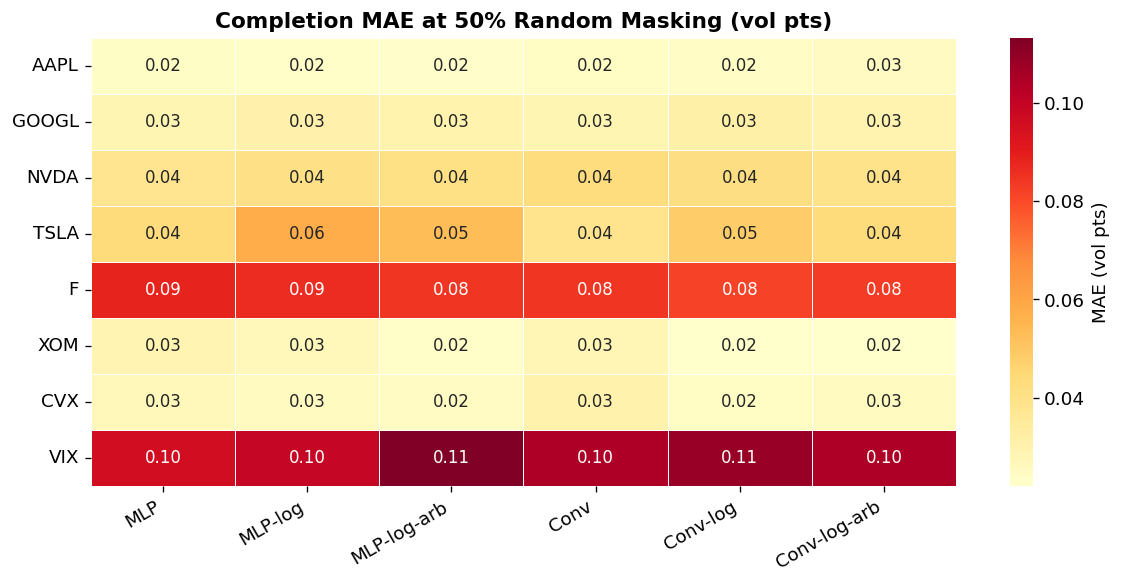


Completion MAE at 50% masking:
             MLP   MLP-log  MLP-log-arb      Conv  Conv-log  Conv-log-arb
ticker                                                                   
AAPL    0.023672  0.023011     0.022469  0.024308  0.024067      0.025082
GOOGL   0.028803  0.030672     0.030014  0.028543  0.031737      0.029911
NVDA    0.038152  0.040467     0.040846  0.042940  0.041956      0.039312
TSLA    0.043129  0.058032     0.053242  0.038496  0.048494      0.043504
F       0.088429  0.086268     0.084537  0.084535  0.081886      0.083124
XOM     0.029038  0.027032     0.023228  0.027855  0.022092      0.022316
CVX     0.026813  0.025337     0.024865  0.030481  0.024390      0.025387
VIX     0.095815  0.099139     0.113223  0.104489  0.108425      0.104508


In [23]:
rows = []
for ticker in TICKERS:
    csv = OUT_ROOT / ticker / 'random_masks.csv'
    if not csv.exists():
        continue
    df = pd.read_csv(csv)
    for variant in VARIANTS:
        sub = df[(df['variant'] == variant) & (df['mask_ratio'].round(2) == 0.50)]
        if sub.empty:
            continue
        rows.append({'ticker': ticker, 'variant': variant,
                     'mae50': sub['mae_vp'].values[0]})

summary_df = pd.DataFrame(rows)
pivot = summary_df.pivot(index='ticker', columns='variant', values='mae50')
pivot = pivot.reindex(index=TICKERS, columns=VARIANTS)
pivot.columns = [VARIANT_LABELS[v] for v in pivot.columns]
pivot.to_csv(OUT_ROOT / 'summary' / 'completion_heatmap.csv')

fig, ax = plt.subplots(figsize=(10, 5))
mask_nan = pivot.isna()
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='YlOrRd',
    mask=mask_nan, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'MAE (vol pts)'},
    annot_kws={'size': 10},
)
ax.set_title('Completion MAE at 50% Random Masking (vol pts)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_ROOT / 'summary' / 'plots' / 'completion_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nCompletion MAE at 50% masking:')
print(pivot.to_string())

In [24]:
# ── Full random mask table at all ratios ──────────────────────────────────────
all_rows = []
for ticker in TICKERS:
    csv = OUT_ROOT / ticker / 'random_masks.csv'
    if not csv.exists():
        continue
    df = pd.read_csv(csv)
    df['ticker'] = ticker
    all_rows.append(df)

all_df = pd.concat(all_rows, ignore_index=True)
all_df['label'] = all_df['variant'].map(VARIANT_LABELS)

# Summary: best variant per ticker at each ratio
best_per_ticker = (
    all_df
    .groupby(['ticker', 'mask_ratio'])
    .apply(lambda g: g.loc[g['mae_vp'].idxmin(), ['variant', 'mae_vp', 'rmse_vp']])
    .reset_index()
)
best_per_ticker.to_csv(OUT_ROOT / 'summary' / 'best_variant_per_ticker.csv', index=False)
print('Best variant per ticker at each mask ratio:')
best_50 = best_per_ticker[best_per_ticker['mask_ratio'].round(2) == 0.50]
print(best_50[['ticker', 'variant', 'mae_vp']].to_string(index=False))

Best variant per ticker at each mask ratio:
ticker     variant   mae_vp
  AAPL mlp_log_arb 0.022469
   CVX    conv_log 0.024390
     F    conv_log 0.081886
 GOOGL        conv 0.028543
  NVDA         mlp 0.038152
  TSLA        conv 0.038496
   VIX         mlp 0.095815
   XOM    conv_log 0.022092


## 7. Structured Mask Cross-Ticker Summary

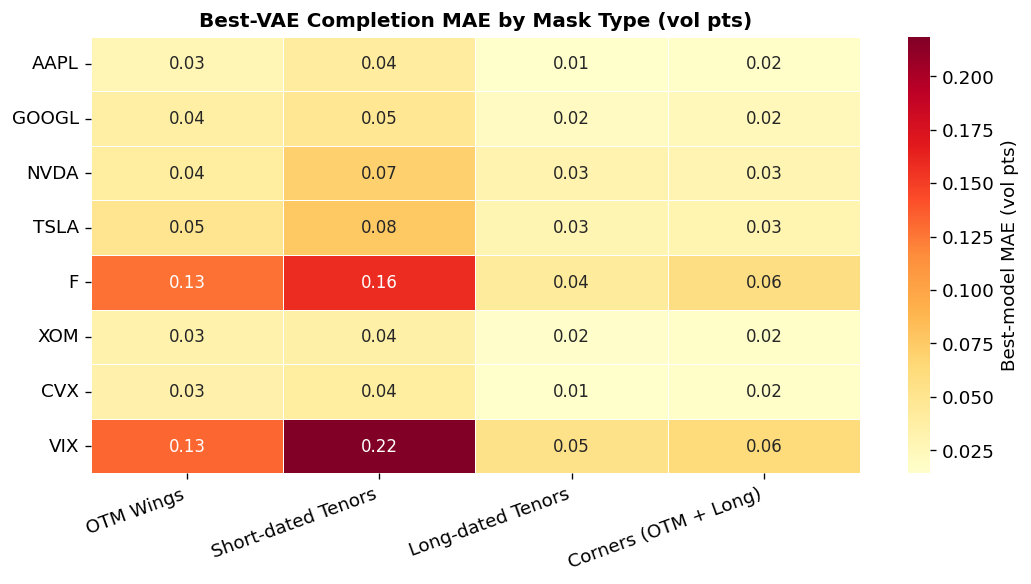

In [25]:
struct_rows = []
for ticker in TICKERS:
    csv = OUT_ROOT / ticker / 'structured_masks.csv'
    if not csv.exists():
        continue
    df = pd.read_csv(csv)
    df['ticker'] = ticker
    struct_rows.append(df)

struct_all = pd.concat(struct_rows, ignore_index=True)
struct_all['label'] = struct_all['variant'].map(VARIANT_LABELS)

# Pivot: ticker × mask_type, best VAE MAE
struct_best = (
    struct_all
    .groupby(['ticker', 'mask_type'])['mae_vp']
    .min()
    .unstack('mask_type')
    .reindex(index=TICKERS, columns=STRUCTURED_TYPES)
)
struct_best.columns = [STRUCT_LABELS[c] for c in struct_best.columns]
struct_best.to_csv(OUT_ROOT / 'summary' / 'structured_best.csv')

fig2, ax2 = plt.subplots(figsize=(9, 5))
sns.heatmap(
    struct_best, annot=True, fmt='.2f', cmap='YlOrRd',
    ax=ax2, linewidths=0.5,
    cbar_kws={'label': 'Best-model MAE (vol pts)'},
    annot_kws={'size': 10},
)
ax2.set_title('Best-VAE Completion MAE by Mask Type (vol pts)', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_ROOT / 'summary' / 'plots' / 'structured_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Thesis Interpretation

Key findings to be incorporated into the thesis.

In [26]:
print('=' * 70)
print('P4 SURFACE COMPLETION — THESIS INTERPRETATION')
print('=' * 70)

if not all_df.empty:
    # 0% masking == reconstruction MAE (sanity check)
    baseline = all_df[all_df['mask_ratio'].round(2) == 0.0]
    print(f'\nSanity check — 0% mask = reconstruction MAE:')
    for ticker in TICKERS:
        sub = baseline[baseline['ticker'] == ticker]
        if sub.empty: continue
        best = sub.sort_values('mae_vp').iloc[0]
        print(f'  {ticker:5s}: {best["mae_vp"]:.3f} vp  ({VARIANT_LABELS[best["variant"]]})')

    print(f'\nCompletion MAE at 50% random masking (best model per ticker):')
    for ticker in TICKERS:
        sub = all_df[(all_df['ticker'] == ticker) &
                     (all_df['mask_ratio'].round(2) == 0.50)]
        if sub.empty: continue
        best = sub.sort_values('mae_vp').iloc[0]
        base = baseline[(baseline['ticker'] == ticker) &
                        (baseline['variant'] == best['variant'])]
        recon_mae = base['mae_vp'].values[0] if not base.empty else float('nan')
        pct_inc = (best['mae_vp'] - recon_mae) / recon_mae * 100 if recon_mae else float('nan')
        print(f'  {ticker:5s}: {best["mae_vp"]:.3f} vp  '
              f'(+{pct_inc:.0f}% vs 0% mask)  '
              f'[{VARIANT_LABELS[best["variant"]]}]')

    print(f'\nAt 90% masking (extreme) — best model per ticker:')
    for ticker in TICKERS:
        sub = all_df[(all_df['ticker'] == ticker) &
                     (all_df['mask_ratio'].round(2) == 0.90)]
        if sub.empty: continue
        best = sub.sort_values('mae_vp').iloc[0]
        print(f'  {ticker:5s}: {best["mae_vp"]:.3f} vp  ({VARIANT_LABELS[best["variant"]]})')

print('\n' + '=' * 70)
print('KEY INSIGHTS')
print('=' * 70)

P4 SURFACE COMPLETION — THESIS INTERPRETATION

Sanity check — 0% mask = reconstruction MAE:
  AAPL : 0.011 vp  (MLP-log)
  GOOGL: 0.014 vp  (MLP-log)
  NVDA : 0.018 vp  (MLP)
  TSLA : 0.026 vp  (MLP)
  F    : 0.074 vp  (MLP-log)
  XOM  : 0.018 vp  (MLP-log-arb)
  CVX  : 0.017 vp  (MLP-log)
  VIX  : 0.071 vp  (MLP)

Completion MAE at 50% random masking (best model per ticker):
  AAPL : 0.022 vp  (+105% vs 0% mask)  [MLP-log-arb]
  GOOGL: 0.029 vp  (+102% vs 0% mask)  [Conv]
  NVDA : 0.038 vp  (+108% vs 0% mask)  [MLP]
  TSLA : 0.038 vp  (+42% vs 0% mask)  [Conv]
  F    : 0.082 vp  (+11% vs 0% mask)  [Conv-log]
  XOM  : 0.022 vp  (+25% vs 0% mask)  [Conv-log]
  CVX  : 0.024 vp  (+43% vs 0% mask)  [Conv-log]
  VIX  : 0.096 vp  (+35% vs 0% mask)  [MLP]

At 90% masking (extreme) — best model per ticker:
  AAPL : 0.034 vp  (Conv-log)
  GOOGL: 0.045 vp  (Conv)
  NVDA : 0.062 vp  (MLP)
  TSLA : 0.061 vp  (Conv)
  F    : 0.093 vp  (Conv-log-arb)
  XOM  : 0.028 vp  (Conv-log)
  CVX  : 0.034 vp  